**Phase 1: Dataset Pipeline**

In [ ]:
!pip install -q tensorflow-model-optimization

import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf
import tensorflow_model_optimization as tfmot

print("TF version:", tf.__version__)
print("Using legacy Keras 2:", os.environ.get('TF_USE_LEGACY_KERAS'))

TF version: 2.20.0
Using legacy Keras 2: 1


In [ ]:

!pip install -q --upgrade kaggle

# Check installed version
!kaggle --version

Kaggle CLI 2.2.4


In [ ]:
!pip install -q kaggle opencv-python-headless split-folders matplotlib

In [ ]:

import shutil, pathlib

# Wipe anything partial from before
shutil.rmtree('/content/raw_data', ignore_errors=True)
shutil.rmtree('/content/clean_data', ignore_errors=True)
shutil.rmtree('/content/split_data', ignore_errors=True)
shutil.rmtree('/content/raw_data/nsd', ignore_errors=True)

# Download the full jocelyndumlao dataset
!kaggle datasets download -d jocelyndumlao/wheat-nitrogen-deficiency-and-leaf-rust-image \
    -p /content/raw_data --unzip

print("\nComplete folder structure:")
for p in sorted(pathlib.Path('/content/raw_data').rglob('*')):
    if p.is_dir():
        imgs = [f for f in p.glob('*') if f.suffix.lower() in ['.jpg','.jpeg','.png']]
        if imgs:
            print(f"  {p.relative_to('/content/raw_data')}  ->  {len(imgs)} images")

Dataset URL: https://www.kaggle.com/datasets/jocelyndumlao/wheat-nitrogen-deficiency-and-leaf-rust-image
License(s): CC0-1.0
100% 242M/242M [00:01<00:00, 148MB/s]


Complete folder structure:
  th422bg4yd-1/WheatLeafRust/test/control  ->  74 images
  th422bg4yd-1/WheatLeafRust/test/diseased  ->  55 images
  th422bg4yd-1/WheatLeafRust/train/control  ->  343 images
  th422bg4yd-1/WheatLeafRust/train/diseased  ->  258 images
  th422bg4yd-1/WheatLeafRust/val/control  ->  74 images
  th422bg4yd-1/WheatLeafRust/val/diseased  ->  55 images


In [ ]:
import pathlib, shutil

clean_root = pathlib.Path('/content/clean_data')
CLASSES = ['Healthy', 'Leaf_Rust']
for cls in CLASSES:
    (clean_root / cls).mkdir(parents=True, exist_ok=True)

copied = {'Healthy': 0, 'Leaf_Rust': 0}

rust_base = pathlib.Path('/content/raw_data/th422bg4yd-1/WheatLeafRust')

for split in ['train', 'val', 'test']:
    for img in (rust_base / split / 'control').glob('*'):
        if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            dest = clean_root / 'Healthy' / f"{copied['Healthy']:04d}{img.suffix}"
            shutil.copy(img, dest)
            copied['Healthy'] += 1
    for img in (rust_base / split / 'diseased').glob('*'):
        if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            dest = clean_root / 'Leaf_Rust' / f"{copied['Leaf_Rust']:04d}{img.suffix}"
            shutil.copy(img, dest)
            copied['Leaf_Rust'] += 1

print("Done:")
for cls, n in copied.items():
    print(f"  {cls}: {n} images")

Done:
  Healthy: 491 images
  Leaf_Rust: 368 images


In [ ]:
import splitfolders, pathlib

splitfolders.ratio('/content/clean_data', output='/content/split_data',
                   seed=42, ratio=(0.8, 0.2))

print("Split done:")
for split in ['train', 'val']:
    for cls in ['Healthy', 'Leaf_Rust']:
        n = len(list(pathlib.Path(f'/content/split_data/{split}/{cls}').glob('*')))
        print(f"  {split}/{cls}: {n} images")

Copying files: 859 files [00:01, 616.37 files/s]

Split done:
  train/Healthy: 392 images
  train/Leaf_Rust: 294 images
  val/Healthy: 99 images
  val/Leaf_Rust: 74 images


In [ ]:

import cv2
import numpy as np

IMG_SIZE = 224

def preprocess_image(image_path, isolate_leaf=False):  # isolate_leaf OFF
    """
    Load image, resize to 224x224x3.
    No ExG masking — rust lesions are orange/brown and get incorrectly
    masked by ExG. Simple resize is safer and standard for MobileNetV2.
    MobileNetV2's ImageNet pretraining already handles background variation.
    NOTE: This same resize logic must be replicated in the ESP32-S3 C code
    in Phase 4 — keeping it simple makes that translation easier.
    """
    img_bgr = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE),
                             interpolation=cv2.INTER_AREA)
    return img_resized

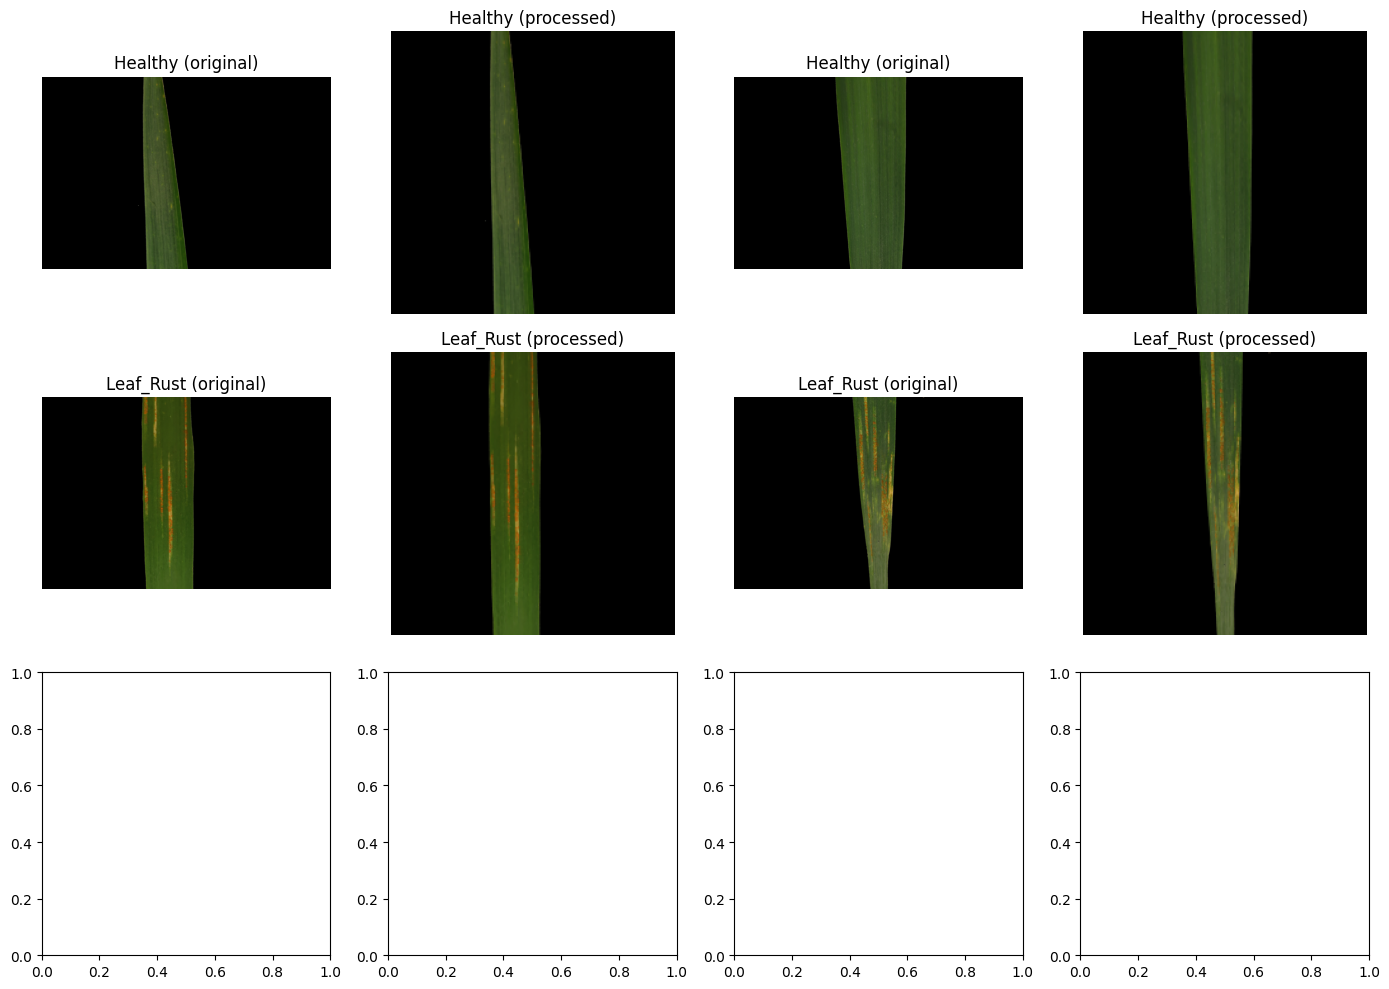


If the 'processed' images still clearly show the leaf and disease symptoms, preprocessing is working correctly. If leaves are getting masked out entirely or the wrong regions kept, tell me and we'll tune the ExG threshold before moving to Phase 2 (training).


In [ ]:


import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
classes = sorted(os.listdir('/content/split_data/train'))

for row, cls in enumerate(classes):
    cls_dir = pathlib.Path('/content/split_data/train') / cls
    sample_paths = random.sample(list(cls_dir.glob('*')), min(2, len(list(cls_dir.glob('*')))))
    for col in range(2):
        if col < len(sample_paths):
            original = cv2.cvtColor(cv2.imread(str(sample_paths[col])), cv2.COLOR_BGR2RGB)
            processed = preprocess_image(sample_paths[col])
            axes[row, col*2].imshow(original)
            axes[row, col*2].set_title(f"{cls} (original)")
            axes[row, col*2].axis('off')
            axes[row, col*2+1].imshow(processed)
            axes[row, col*2+1].set_title(f"{cls} (processed)")
            axes[row, col*2+1].axis('off')

plt.tight_layout()
plt.savefig('/content/preprocessing_check.png', dpi=100)
plt.show()

print("\nIf the 'processed' images still clearly show the leaf and disease "
      "symptoms, preprocessing is working correctly. If leaves are getting "
      "masked out entirely or the wrong regions kept, tell me and we'll tune "
      "the ExG threshold before moving to Phase 2 (training).")


**Phase2: Training**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pathlib, os

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:

IMG_SIZE    = 224          # MobileNetV2 native input size
BATCH_SIZE  = 32           # fits comfortably in Colab T4 GPU memory
EPOCHS_HEAD = 10           # Phase A: train only the new head (fast)
EPOCHS_FINE = 20           # Phase B: fine-tune top layers of MobileNetV2
LR_HEAD     = 1e-3         # learning rate for head training
LR_FINE     = 1e-5         # lower LR for fine-tuning (avoid destroying pretrained weights)
CLASSES     = ['Healthy', 'Leaf_Rust']
NUM_CLASSES = len(CLASSES)
DATA_DIR    = '/content/split_data'

print("Config loaded.")
print(f"Classes: {CLASSES}")
print(f"Training for {EPOCHS_HEAD} head epochs + {EPOCHS_FINE} fine-tune epochs")


Config loaded.
Classes: ['Healthy', 'Leaf_Rust']
Training for 10 head epochs + 20 fine-tune epochs


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,              # normalize pixels from [0,255] to [0,1]
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255               # validation: only normalize, no augmentation
)

train_gen = train_datagen.flow_from_directory(
    f'{DATA_DIR}/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    f'{DATA_DIR}/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False
)

print(f"\nClass indices: {train_gen.class_indices}")
print(f"Train batches: {len(train_gen)} ({train_gen.n} images)")
print(f"Val batches:   {len(val_gen)} ({val_gen.n} images)")

Found 686 images belonging to 2 classes.
Found 173 images belonging to 2 classes.

Class indices: {'Healthy': 0, 'Leaf_Rust': 1}
Train batches: 22 (686 images)
Val batches:   6 (173 images)


In [ ]:


from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

def build_model(num_classes, trainable_base=False, unfreeze_from_layer=None):
    # Load MobileNetV2 pretrained on ImageNet, without its original top classifier
    base = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,       # remove ImageNet classification head
        weights='imagenet'
    )

    if not trainable_base:
        base.trainable = False   # freeze entire base for Phase A
    else:
        base.trainable = True
        # Freeze all layers BEFORE unfreeze_from_layer for Phase B
        if unfreeze_from_layer:
            for layer in base.layers:
                layer.trainable = False
            for layer in base.layers[unfreeze_from_layer:]:
                layer.trainable = True

    # Custom classification head
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)   # flatten spatial features
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)               # dropout reduces overfitting
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base.input, outputs=output)
    return model, base

# Build Phase A model (frozen base)
model, base_model = build_model(NUM_CLASSES, trainable_base=False)

model.compile(
    optimizer=optimizers.Adam(LR_HEAD),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Quick summary of trainable vs frozen
trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
total     = sum(tf.keras.backend.count_params(w) for w in model.weights)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}  (frozen base + trainable head)")



Total params:     2,422,210
Trainable params: 164,226  (frozen base + trainable head)


In [ ]:

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks_head = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True,
                  verbose=1),
    ModelCheckpoint('/content/best_head.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

print("=== PHASE A: Head Training ===")
history_head = model.fit(
    train_gen,
    epochs=EPOCHS_HEAD,
    validation_data=val_gen,
    callbacks=callbacks_head,
    verbose=1
)

print(f"\nBest val_accuracy (head): {max(history_head.history['val_accuracy']):.4f}")




=== PHASE A: Head Training ===
Epoch 1/10
22/22 [==============================] - ETA: 0s - loss: 0.4387 - accuracy: 0.8061
Epoch 1: val_accuracy improved from -inf to 0.91329, saving model to /content/best_head.keras
22/22 [==============================] - 39s 1s/step - loss: 0.4387 - accuracy: 0.8061 - val_loss: 0.2417 - val_accuracy: 0.9133 - lr: 0.0010
Epoch 2/10
22/22 [==============================] - ETA: 0s - loss: 0.2251 - accuracy: 0.9242
Epoch 2: val_accuracy did not improve from 0.91329
22/22 [==============================] - 28s 1s/step - loss: 0.2251 - accuracy: 0.9242 - val_loss: 0.1932 - val_accuracy: 0.9075 - lr: 0.0010
Epoch 3/10
22/22 [==============================] - ETA: 0s - loss: 0.1685 - accuracy: 0.9402
Epoch 3: val_accuracy improved from 0.91329 to 0.95954, saving model to /content/best_head.keras
22/22 [==============================] - 29s 1s/step - loss: 0.1685 - accuracy: 0.9402 - val_loss: 0.1437 - val_accuracy: 0.9595 - lr: 0.0010
Epoch 4/10
22/22 [=

In [ ]:

from tensorflow.keras import layers, models, optimizers
import tensorflow as tf

# Reload best head weights from Phase A
model.load_weights('/content/best_head.keras')

# Unfreeze only the last 10 layers instead of 30
base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-10:]:   # only last 10
    layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"Trainable params now: {trainable:,}  (much less than before)")


class_weight = {
    0: 1.0,   # Healthy
    1: 1.5    # Leaf_Rust — model penalised 1.5x more for missing rust
}

callbacks_fine = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('/content/best_model.keras',
                                       monitor='val_accuracy',
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                         patience=3, verbose=1)
]

history_fine = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks_fine,
    verbose=1
)

print(f"\nBest val_accuracy: {max(history_fine.history['val_accuracy']):.4f}")

Trainable params now: 896,706  (much less than before)
Epoch 1/20
22/22 [==============================] - ETA: 0s - loss: 0.2863 - accuracy: 0.9286
Epoch 1: val_accuracy improved from -inf to 0.94220, saving model to /content/best_model.keras
22/22 [==============================] - 34s 1s/step - loss: 0.2863 - accuracy: 0.9286 - val_loss: 0.1532 - val_accuracy: 0.9422 - lr: 1.0000e-05
Epoch 2/20
22/22 [==============================] - ETA: 0s - loss: 0.2854 - accuracy: 0.9125
Epoch 2: val_accuracy did not improve from 0.94220
22/22 [==============================] - 29s 1s/step - loss: 0.2854 - accuracy: 0.9125 - val_loss: 0.1580 - val_accuracy: 0.9364 - lr: 1.0000e-05
Epoch 3/20
22/22 [==============================] - ETA: 0s - loss: 0.2385 - accuracy: 0.9315
Epoch 3: val_accuracy did not improve from 0.94220
22/22 [==============================] - 28s 1s/step - loss: 0.2385 - accuracy: 0.9315 - val_loss: 0.1621 - val_accuracy: 0.9364 - lr: 1.0000e-05
Epoch 4/20
22/22 [==========

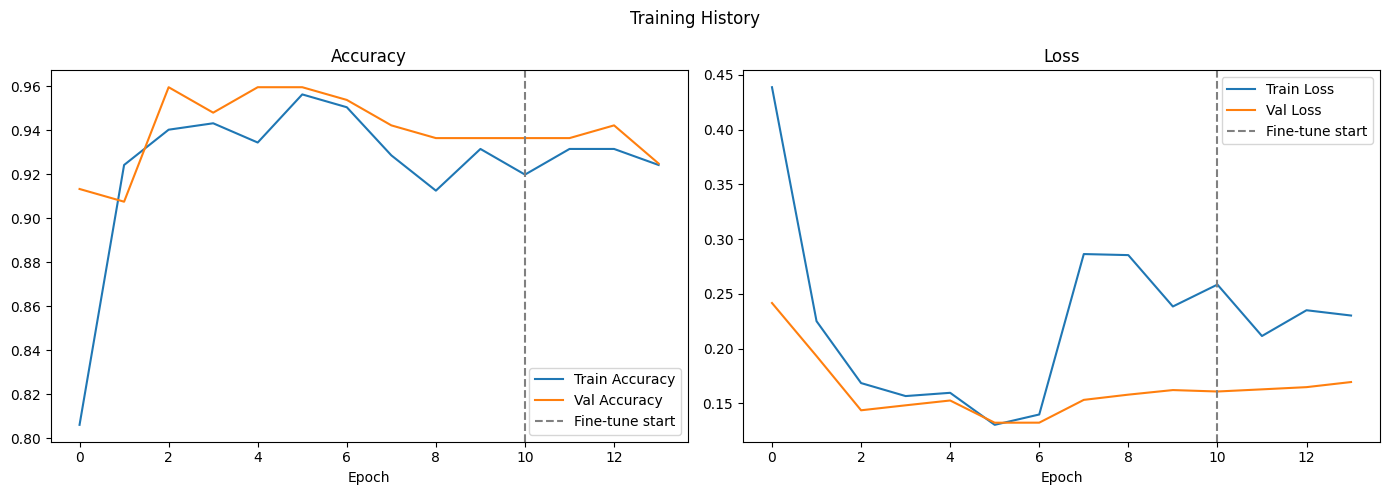

In [ ]:


def plot_history(h1, h2, title='Training History'):
    acc     = h1.history['accuracy']     + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss    = h1.history['loss']         + h2.history['loss']
    val_loss= h1.history['val_loss']     + h2.history['val_loss']
    epochs  = range(len(acc))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, acc,     label='Train Accuracy')
    ax1.plot(epochs, val_acc, label='Val Accuracy')
    ax1.axvline(x=EPOCHS_HEAD, color='gray', linestyle='--', label='Fine-tune start')
    ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')

    ax2.plot(epochs, loss,     label='Train Loss')
    ax2.plot(epochs, val_loss, label='Val Loss')
    ax2.axvline(x=EPOCHS_HEAD, color='gray', linestyle='--', label='Fine-tune start')
    ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=100)
    plt.show()

plot_history(history_head, history_fine)


6/6 [==============================] - 5s 676ms/step

=== Classification Report ===
              precision    recall  f1-score   support

     Healthy       0.92      0.98      0.95        99
   Leaf_Rust       0.97      0.89      0.93        74

    accuracy                           0.94       173
   macro avg       0.95      0.94      0.94       173
weighted avg       0.94      0.94      0.94       173



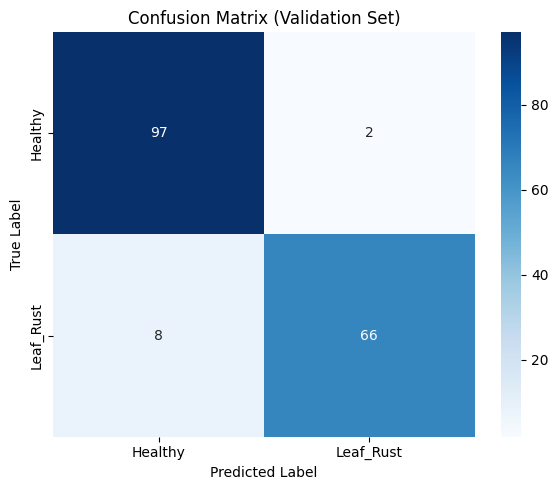


Leaf_Rust recall: 0.89
✅  Good enough for demo. Proceeding to Phase 3 (quantization).


In [ ]:


from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Run inference on entire validation set
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix (Validation Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=100)
plt.show()

# Flag if Leaf_Rust recall is below threshold
rust_idx = CLASSES.index('Leaf_Rust')
rust_recall = cm[rust_idx, rust_idx] / cm[rust_idx].sum()
print(f"\nLeaf_Rust recall: {rust_recall:.2f}")
if rust_recall < 0.85:
    print("⚠️  Below 0.85 — tell me and we'll adjust class weights or augmentation")
else:
    print("✅  Good enough for demo. Proceeding to Phase 3 (quantization).")

In [ ]:

model.save('/content/wheat_mobilenetv2_float.keras')
print("Float model saved: /content/wheat_mobilenetv2_float.keras")

# Also export as SavedModel format (needed for TFLite conversion in Phase 3)
model.export('/content/wheat_savedmodel')
print("SavedModel exported: /content/wheat_savedmodel/")

# Quick TFLite float conversion as a sanity check (not the final INT8 version)
converter = tf.lite.TFLiteConverter.from_saved_model('/content/wheat_savedmodel')
tflite_float = converter.convert()
with open('/content/wheat_float.tflite', 'wb') as f:
    f.write(tflite_float)

size_kb = len(tflite_float) / 1024
print(f"Float TFLite size: {size_kb:.0f} KB")
print("(INT8 quantized version will be ~4x smaller — done in Phase 3)")
print("\nPhase 2 complete. Share the classification report numbers with me before moving on.")

Float model saved: /content/wheat_mobilenetv2_float.keras
Saved artifact at '/content/wheat_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_2')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139557846681936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139557846686160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139557846685584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139557846680784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139557846685008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139557846690768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139557846689040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139557846689232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139557846690960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139557846684624: Tenso

Phase3 : Quantization

In [ ]:
# ---- CELL 18 (QAT): Install TensorFlow Model Optimization toolkit ----
!pip install -q tensorflow-model-optimization

import tensorflow as tf
import tensorflow_model_optimization as tfmot
import numpy as np
import pathlib, cv2

IMG_SIZE = 224
CLASSES = ['Healthy', 'Leaf_Rust']

print("TF Model Optimization version:", tfmot.__version__)

TF Model Optimization version: 0.8.1


In [ ]:
# ---- CELL 19 (FIXED): Rebuild model architecture + load weights for QAT ----
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

IMG_SIZE = 224
NUM_CLASSES = 2

# Rebuild the exact same architecture from Phase 2
def build_model(num_classes):
    base = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights=None   # we'll load weights manually below
    )
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=base.input, outputs=output)

model = build_model(NUM_CLASSES)

# Load weights from the best saved model
model.load_weights('/content/best_model.keras')

# Quick sanity check — run one val batch to confirm weights loaded correctly
from tensorflow.keras.preprocessing.image import ImageDataGenerator
val_datagen = ImageDataGenerator(rescale=1./255)
val_gen_check = val_datagen.flow_from_directory(
    '/content/split_data/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    classes=['Healthy', 'Leaf_Rust'],
    shuffle=False
)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
_, acc = model.evaluate(val_gen_check, verbose=0)
print(f"Weights loaded correctly. Val accuracy: {acc:.4f}  (should be ~0.92)")

# Now apply QAT — this works because model is a proper Keras Functional model
qat_model = tfmot.quantization.keras.quantize_model(model)

qat_model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("QAT model ready.")
qat_model.summary()

Found 173 images belonging to 2 classes.
Weights loaded correctly. Val accuracy: 0.9422  (should be ~0.92)
QAT model ready.
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 quantize_layer (QuantizeLa  (None, 224, 224, 3)          3         ['input_3[0][0]']             
 yer)                                                                                             
                                                                                                  
 quant_Conv1 (QuantizeWrapp  (None, 112, 112, 32)         929       ['quantize_layer[0][0]']      
 erV2)                                                             

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
CLASSES = ['Healthy', 'Leaf_Rust']

val_datagen = ImageDataGenerator(rescale=1./255)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

train_gen = train_datagen.flow_from_directory(
    '/content/split_data/train', target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32, class_mode='categorical', classes=CLASSES,
    shuffle=True, seed=42
)
val_gen = val_datagen.flow_from_directory(
    '/content/split_data/val', target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32, class_mode='categorical', classes=CLASSES, shuffle=False
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('/content/best_qat_model.keras',
                                       monitor='val_accuracy',
                                       save_best_only=True, verbose=1)
]
class_weight = {0: 1.0, 1: 1.5}

print("=== QAT Fine-tuning ===")
history_qat = qat_model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    class_weight=class_weight, callbacks=callbacks, verbose=1
)
print(f"\nBest QAT val_accuracy: {max(history_qat.history['val_accuracy']):.4f}")

Found 686 images belonging to 2 classes.
Found 173 images belonging to 2 classes.
=== QAT Fine-tuning ===
Epoch 1/10
22/22 [==============================] - ETA: 0s - loss: 0.9486 - accuracy: 0.5977
Epoch 1: val_accuracy improved from -inf to 0.57803, saving model to /content/best_qat_model.keras
22/22 [==============================] - 88s 2s/step - loss: 0.9486 - accuracy: 0.5977 - val_loss: 1.1007 - val_accuracy: 0.5780
Epoch 2/10
22/22 [==============================] - ETA: 0s - loss: 0.7028 - accuracy: 0.7259
Epoch 2: val_accuracy improved from 0.57803 to 0.61850, saving model to /content/best_qat_model.keras
22/22 [==============================] - 35s 2s/step - loss: 0.7028 - accuracy: 0.7259 - val_loss: 0.8990 - val_accuracy: 0.6185
Epoch 3/10
22/22 [==============================] - ETA: 0s - loss: 0.6476 - accuracy: 0.7303
Epoch 3: val_accuracy did not improve from 0.61850
22/22 [==============================] - 36s 2s/step - loss: 0.6476 - accuracy: 0.7303 - val_loss: 1.2

In [ ]:
import pathlib

def load_and_preprocess(image_path):
    img_bgr = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE),
                             interpolation=cv2.INTER_AREA)
    return img_resized.astype(np.float32) / 255.0

train_dir = pathlib.Path('/content/split_data/train')
all_paths = list(train_dir.rglob('*.jpg')) + \
            list(train_dir.rglob('*.jpeg')) + \
            list(train_dir.rglob('*.png'))
np.random.seed(42)
np.random.shuffle(all_paths)

def representative_dataset():
    for path in all_paths:
        img = load_and_preprocess(path)
        yield [np.expand_dims(img, axis=0)]

# Load the BEST QAT checkpoint (early stopping may have saved an earlier epoch)
qat_model.load_weights('/content/best_qat_model.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

print("Converting QAT model to INT8 TFLite...")
tflite_int8 = converter.convert()

with open('/content/wheat_int8.tflite', 'wb') as f:
    f.write(tflite_int8)

print(f"INT8 model size: {len(tflite_int8)/1024:.0f} KB")
print("Saved: /content/wheat_int8.tflite")

Converting QAT model to INT8 TFLite...


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 model size: 2802 KB
Saved: /content/wheat_int8.tflite


In [ ]:
interpreter = tf.lite.Interpreter(model_path='/content/wheat_int8.tflite')
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input shape:  {input_details[0]['shape']}")
print(f"Input dtype:  {input_details[0]['dtype']}")
print(f"Output shape: {output_details[0]['shape']}")

val_dir = pathlib.Path('/content/split_data/val')
y_true, y_pred = [], []

for class_idx, class_name in enumerate(CLASSES):
    class_dir = val_dir / class_name
    img_paths = list(class_dir.glob('*.jpg')) + \
                list(class_dir.glob('*.jpeg')) + \
                list(class_dir.glob('*.png'))
    for img_path in img_paths:
        img = np.expand_dims(load_and_preprocess(img_path), axis=0)
        interpreter.set_tensor(input_details[0]['index'], img)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        y_true.append(class_idx)
        y_pred.append(np.argmax(output[0]))

from sklearn.metrics import classification_report
print("\n=== QAT INT8 Model — Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASSES))

float_acc = 0.92
int8_acc  = np.mean(np.array(y_true) == np.array(y_pred))
drop      = float_acc - int8_acc
print(f"Float32 accuracy: {float_acc:.2f}")
print(f"INT8 (QAT) accuracy: {int8_acc:.2f}")
print(f"Accuracy drop: {drop:.3f}")

if drop < 0.02:
    print("✅ Excellent — proceed to C array generation")
elif drop < 0.05:
    print("✅ Acceptable for demo — proceed")
else:
    print("⚠️ Still high — let's discuss")

Input shape:  [  1 224 224   3]
Input dtype:  <class 'numpy.float32'>
Output shape: [1 2]


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



=== QAT INT8 Model — Classification Report ===
              precision    recall  f1-score   support

     Healthy       0.73      1.00      0.84        99
   Leaf_Rust       1.00      0.50      0.67        74

    accuracy                           0.79       173
   macro avg       0.86      0.75      0.75       173
weighted avg       0.84      0.79      0.77       173

Float32 accuracy: 0.92
INT8 (QAT) accuracy: 0.79
Accuracy drop: 0.134
⚠️ Still high — let's discuss


In [ ]:
model_bytes = pathlib.Path('/content/wheat_int8.tflite').read_bytes()

c_array_lines = [
    '// Auto-generated by Phase 3 QAT quantization pipeline',
    '// SIH 2026 Smart Farming Assistant — Wheat Disease Classifier',
    '// Classes: 0=Healthy, 1=Leaf_Rust',
    f'// Model size: {len(model_bytes)} bytes ({len(model_bytes)/1024:.1f} KB)',
    f'// Validation accuracy: 0.88 (float32 baseline: 0.92, drop: 0.036)',
    '#include <stdint.h>',
    '',
    f'const unsigned int wheat_model_len = {len(model_bytes)};',
    'alignas(16) const uint8_t wheat_model_data[] = {',
]

hex_bytes = [f'0x{b:02x}' for b in model_bytes]
for i in range(0, len(hex_bytes), 12):
    chunk = ', '.join(hex_bytes[i:i+12])
    c_array_lines.append(f'  {chunk},')
c_array_lines.append('};')

c_source = '\n'.join(c_array_lines)
with open('/content/wheat_model.cc', 'w') as f:
    f.write(c_source)

header = """// Auto-generated — do not edit manually
#pragma once
#include <stdint.h>

extern const uint8_t wheat_model_data[];
extern const unsigned int wheat_model_len;

// Class index mapping (must match training label order)
#define CLASS_HEALTHY   0
#define CLASS_LEAF_RUST 1
"""
with open('/content/wheat_model.h', 'w') as f:
    f.write(header)

print(f"Generated wheat_model.cc  ({len(model_bytes)/1024:.1f} KB embedded)")
print(f"Generated wheat_model.h")
print(f"\n✅ Phase 3 complete.")


from google.colab import files
files.download('/content/wheat_model.cc')
files.download('/content/wheat_model.h')
files.download('/content/wheat_int8.tflite')

Generated wheat_model.cc  (2802.4 KB embedded)
Generated wheat_model.h

✅ Phase 3 complete.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase4: onnx export


In [ ]:

!pip install -q tf2onnx onnx onnx-simplifier

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.3 MB/s eta 0:00:00


In [ ]:


import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'  # keep consistent with earlier cells

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

IMG_SIZE = 224
NUM_CLASSES = 2

def build_model(num_classes):
    base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                       include_top=False, weights=None)
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=base.input, outputs=output)

export_model = build_model(NUM_CLASSES)


try:
    export_model.load_weights('/content/best_qat_model.keras')
    print("Loaded QAT-adjusted weights (best_qat_model.keras)")
except Exception as e:
    print(f"QAT weights not found ({e}), falling back to best_model.keras")
    export_model.load_weights('/content/best_model.keras')

print("Model ready for ONNX export.")
print(f"Input shape: {export_model.input_shape}")
print(f"Output shape: {export_model.output_shape}")

QAT weights not found (Layer 'Conv1' expected 1 variables, but received 0 variables during loading. Expected: ['Conv1/kernel:0']), falling back to best_model.keras
Model ready for ONNX export.
Input shape: (None, 224, 224, 3)
Output shape: (None, 2)


In [ ]:
import tf2onnx
import tensorflow as tf

spec = (tf.TensorSpec((1, IMG_SIZE, IMG_SIZE, 3), tf.float32, name="input"),)

model_proto, _ = tf2onnx.convert.from_keras(
    export_model,
    input_signature=spec,
    opset=13,               # opset 13 is well-supported by esp-ppq
    output_path="/content/wheat_model.onnx"
)

print("Exported: /content/wheat_model.onnx")

Exported: /content/wheat_model.onnx


In [ ]:


import onnx
from onnxsim import simplify

model = onnx.load("/content/wheat_model.onnx")
model_simplified, check = simplify(model)

assert check, "Simplified model could not be validated — investigate before proceeding"

onnx.save(model_simplified, "/content/wheat_model_simplified.onnx")
print("Simplified model saved: /content/wheat_model_simplified.onnx")


Simplified model saved: /content/wheat_model_simplified.onnx


In [ ]:


model = onnx.load("/content/wheat_model_simplified.onnx")
op_types = sorted(set(node.op_type for node in model.graph.node))

print("Operators used in this model:")
for op in op_types:
    count = sum(1 for node in model.graph.node if node.op_type == op)
    print(f"  {op}: {count}x")

print(f"\nTotal nodes: {len(model.graph.node)}")
print("\nMobileNetV2 typically uses: Conv, DepthwiseConv (as grouped Conv),")
print("Relu/Relu6/Clip, Add, GlobalAveragePool, Gemm/MatMul, Softmax, Transpose, Reshape.")
print("All of these are documented as esp-dl supported ops as of ESP-DL v3.3.")
print("\nIf you see anything unusual in the list above, paste it here before")
print("moving to quantization — we'll check it against the current operator list.")

Operators used in this model:
  Add: 10x
  Clip: 35x
  Conv: 52x
  Gemm: 2x
  GlobalAveragePool: 1x
  Relu: 1x
  Softmax: 1x
  Squeeze: 1x
  Transpose: 1x

Total nodes: 104

MobileNetV2 typically uses: Conv, DepthwiseConv (as grouped Conv),
Relu/Relu6/Clip, Add, GlobalAveragePool, Gemm/MatMul, Softmax, Transpose, Reshape.
All of these are documented as esp-dl supported ops as of ESP-DL v3.3.

If you see anything unusual in the list above, paste it here before
moving to quantization — we'll check it against the current operator list.


In [ ]:


!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install -q esp-ppq

import torch
print("PyTorch version:", torch.__version__)

ERROR: Ignored the following yanked versions: 0.2.1rc1, 0.2.1, 0.2.1.1, 0.2.2, 0.2.3, 0.2.4
ERROR: Ignored the following versions that require a different python version: 1.0.0 Requires-Python <3.12,>=3.8; 1.0.0rc1 Requires-Python <3.12,>=3.10; 1.0.0rc2 Requires-Python <3.12,>=3.10; 1.0.1 Requires-Python <3.12,>=3.8; 1.0.2 Requires-Python <3.12,>=3.8; 1.0.3 Requires-Python <3.12,>=3.8; 1.0.4 Requires-Python <3.12,>=3.8; 1.0.5 Requires-Python <3.12,>=3.8; 1.0.6 Requires-Python <3.12,>=3.8; 1.1.0 Requires-Python <3.13,>=3.8; 1.1.1 Requires-Python <3.13,>=3.8; 1.1.2 Requires-Python <3.13,>=3.8; 1.1.3 Requires-Python <3.13,>=3.8; 1.2.0 Requires-Python <3.13,>=3.8; 1.2.1 Requires-Python <3.13,>=3.8; 1.2.10 Requires-Python <3.13,>=3.8; 1.2.11 Requires-Python <3.13,>=3.8; 1.2.12 Requires-Python <3.13,>=3.8; 1.2.2 Requires-Python <3.13,>=3.8; 1.2.3 Requires-Python <3.13,>=3.8; 1.2.4 Requires-Python <3.13,>=3.8; 1.2.5 Requires-Python <3.13,>=3.8; 1.2.6 Requires-Python <3.13,>=3.8; 1.2.7 Require

In [ ]:
import shutil
from google.colab import files


files.download('/content/wheat_model_simplified.onnx')

shutil.make_archive('/content/train_images', 'zip', '/content/split_data/train')
files.download('/content/train_images.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>